# ETF 申购资金赚钱效应

将每日正份额变化视为净申购，以当日单位净值估算申购金额；使用累计净值计算截至评价日的含分红收益。赚钱资金比例为盈利批次申购金额占全部正净申购金额的比例。

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'mme-matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

候选中文字体 = ['PingFang SC', 'Heiti SC', 'Hiragino Sans GB', 'STHeiti']
已安装字体 = {字体.name for 字体 in font_manager.fontManager.ttflist}
中文字体 = next((字体 for 字体 in 候选中文字体 if 字体 in 已安装字体), None)
if 中文字体 is None:
    raise RuntimeError('未找到可用中文字体，请安装 PingFang SC、Heiti SC 或 Hiragino Sans GB 后重试。')

plt.rcParams['font.sans-serif'] = [中文字体]
plt.rcParams['axes.unicode_minus'] = False
print(f'使用中文字体：{中文字体}')

Matplotlib is building the font cache; this may take a moment.


使用中文字体：PingFang SC


In [2]:
份额文件 = Path('data/etf_shares.parquet')
净值文件 = Path('ETF.xlsx')
评价日 = None  # 例如：'2026-06-30'

if not 份额文件.exists():
    raise FileNotFoundError('未找到 data/etf_shares.parquet，请先运行 download_etf.py。')
if not 净值文件.exists():
    raise FileNotFoundError('未找到 ETF.xlsx。')

In [3]:
份额字段 = {'date', 'fund_code', 'fund_name', 'total_shares'}
净值字段 = {'基金代码', '基金名称', '净值日期', '单位净值(元)', '累计净值(元)'}

份额 = pd.read_parquet(份额文件)
缺失字段 = 份额字段 - set(份额.columns)
if 缺失字段:
    raise ValueError(f'份额数据缺少字段：{", ".join(sorted(缺失字段))}')
份额 = 份额.loc[:, sorted(份额字段)].copy()
份额['fund_code'] = 份额['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
份额['date'] = pd.to_datetime(份额['date'], errors='raise').dt.date
份额['total_shares'] = pd.to_numeric(份额['total_shares'], errors='raise')
if 份额.duplicated(['date', 'fund_code']).any() or (份额['total_shares'] <= 0).any():
    raise ValueError('份额数据包含重复记录或非正份额。')

净值工作表 = pd.read_excel(净值文件, sheet_name=None, engine='openpyxl', dtype={'基金代码': 'string'})
净值列表 = []
for 工作表名, 工作表 in 净值工作表.items():
    缺失字段 = 净值字段 - set(工作表.columns)
    if 缺失字段:
        raise ValueError(f'工作表 {工作表名!r} 缺少字段：{", ".join(sorted(缺失字段))}')
    净值列表.append(工作表.loc[:, list(净值字段)].copy())
净值 = pd.concat(净值列表, ignore_index=True).rename(columns={
    '基金代码': 'fund_code', '基金名称': 'fund_name', '净值日期': 'date',
    '单位净值(元)': 'unit_nav', '累计净值(元)': 'cumulative_nav',
})
净值['fund_code'] = 净值['fund_code'].astype('string').str.replace(r'\.0$', '', regex=True).str.zfill(6)
净值['date'] = pd.to_datetime(净值['date'], errors='raise').dt.date
净值[['unit_nav', 'cumulative_nav']] = 净值[['unit_nav', 'cumulative_nav']].apply(pd.to_numeric, errors='raise')
if 净值.duplicated(['date', 'fund_code']).any() or (净值[['unit_nav', 'cumulative_nav']] <= 0).any().any():
    raise ValueError('净值数据包含重复记录或非正净值。')

基金代码集合 = set(份额['fund_code'])
可用净值 = 净值.loc[净值['fund_code'].isin(基金代码集合)]
缺失基金 = 基金代码集合 - set(可用净值['fund_code'])
if 缺失基金:
    raise ValueError(f'净值数据缺少基金：{", ".join(sorted(缺失基金))}')
if 评价日 is not None:
    可用净值 = 可用净值.loc[可用净值['date'] <= pd.Timestamp(评价日).date()]
共同评价日 = 可用净值.groupby('date')['fund_code'].nunique()
共同评价日 = 共同评价日.index[共同评价日 == len(基金代码集合)]
if 共同评价日.empty:
    raise ValueError('没有覆盖全部 ETF 的共同评价日。')
实际评价日 = max(共同评价日)

份额 = 份额.loc[份额['date'] <= 实际评价日].sort_values(['fund_code', 'date']).copy()
基金名称映射 = 份额.drop_duplicates('fund_code', keep='last').set_index('fund_code')['fund_name']
份额['净申购份额'] = 份额.groupby('fund_code')['total_shares'].diff()
批次明细 = 份额.loc[份额['净申购份额'] > 0].rename(columns={'date': '申购日期'}).copy()
申购日净值 = 净值.rename(columns={'date': '申购日期', 'cumulative_nav': '申购日累计净值'}).loc[:, ['申购日期', 'fund_code', 'unit_nav', '申购日累计净值']]
批次明细 = 批次明细.merge(申购日净值, on=['申购日期', 'fund_code'], how='left', validate='one_to_one')
评价日净值 = 净值.loc[净值['date'] == 实际评价日, ['fund_code', 'cumulative_nav']].rename(columns={'cumulative_nav': '评价日累计净值'})
批次明细 = 批次明细.merge(评价日净值, on='fund_code', how='left', validate='many_to_one')
if 批次明细[['unit_nav', '申购日累计净值', '评价日累计净值']].isna().any().any():
    raise ValueError('部分申购批次缺少净值数据。')
批次明细['估算申购金额'] = 批次明细['净申购份额'] * 批次明细['unit_nav']
批次明细['持有收益率'] = 批次明细['评价日累计净值'] / 批次明细['申购日累计净值'] - 1
批次明细['赚钱'] = 批次明细['持有收益率'] > 0
批次明细['fund_name'] = 批次明细['fund_code'].map(基金名称映射)

汇总 = 批次明细.groupby('fund_code', as_index=False).agg(
    正净申购金额=('估算申购金额', 'sum'),
    赚钱资金金额=('估算申购金额', lambda 金额: 金额[批次明细.loc[金额.index, '赚钱']].sum()),
    申购批次数=('赚钱', 'size'),
)
汇总['fund_name'] = 汇总['fund_code'].map(基金名称映射)
汇总['赚钱资金比例'] = 汇总['赚钱资金金额'] / 汇总['正净申购金额']
总体正净申购金额 = 批次明细['估算申购金额'].sum()
总体赚钱资金金额 = 批次明细.loc[批次明细['赚钱'], '估算申购金额'].sum()
总体 = pd.DataFrame([{
    'fund_code': 'ALL', 'fund_name': '总体', '正净申购金额': 总体正净申购金额,
    '赚钱资金金额': 总体赚钱资金金额, '申购批次数': len(批次明细),
    '赚钱资金比例': 总体赚钱资金金额 / 总体正净申购金额 if 总体正净申购金额 else float('nan'),
}])
汇总 = pd.concat([汇总, 总体], ignore_index=True)

实际评价日：2026-07-13


,基金代码,正净申购金额,赚钱资金金额,申购批次数,基金名称,赚钱资金比例
0,159532,"117,454,400","22,045,200",26,中证2000ETF易方达,18.8%
1,159633,"6,958,645,800","719,193,700",49,中证1000ETF易方达,10.3%
2,510100,"4,600,040,580","2,407,729,590",49,SZ50ETF,52.3%
3,510310,"7,537,250,700","5,236,214,940",33,HS300ETF,69.5%
4,510580,"2,076,173,760","725,689,760",64,ZZ500ETF,35.0%
5,563020,"8,383,047,200","1,630,410,000",102,低波红利,19.4%
6,588080,"10,756,702,200","8,970,835,800",45,科创板50,83.4%
7,ALL,"40,429,314,640","19,712,118,990",368,总体,48.8%


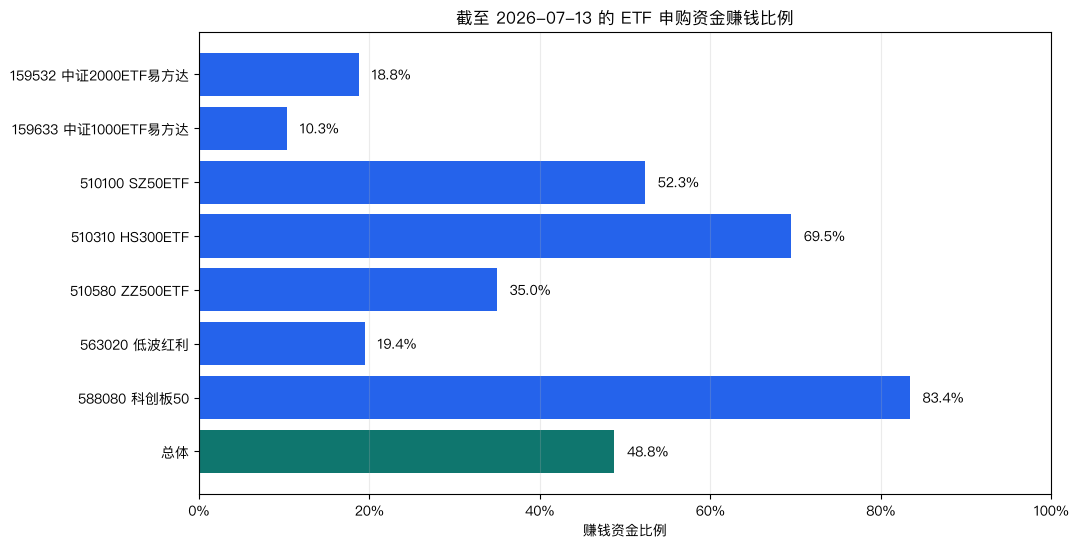

In [4]:
print(f'实际评价日：{实际评价日}')
展示汇总 = 汇总.rename(columns={
    'fund_code': '基金代码', 'fund_name': '基金名称',
})
display(展示汇总.style.format({
    '正净申购金额': '{:,.0f}', '赚钱资金金额': '{:,.0f}', '赚钱资金比例': '{:.1%}',
}))

标签 = ['总体' if 代码 == 'ALL' else f'{代码} {名称}' for 代码, 名称 in zip(汇总['fund_code'], 汇总['fund_name'])]
比例 = 汇总['赚钱资金比例'].fillna(0)
颜色 = ['#0F766E' if 代码 == 'ALL' else '#2563EB' for 代码 in 汇总['fund_code']]
图, 坐标轴 = plt.subplots(figsize=(11, 6))
柱形 = 坐标轴.barh(标签, 比例, color=颜色)
坐标轴.set_xlim(0, 1)
坐标轴.xaxis.set_major_formatter(PercentFormatter(1))
坐标轴.set_xlabel('赚钱资金比例')
坐标轴.set_title(f'截至 {实际评价日} 的 ETF 申购资金赚钱比例')
坐标轴.grid(axis='x', alpha=0.25)
坐标轴.invert_yaxis()
for 柱, 数值 in zip(柱形, 比例):
    坐标轴.text(min(数值 + 0.015, 0.94), 柱.get_y() + 柱.get_height() / 2, f'{数值:.1%}', va='center')
plt.show()

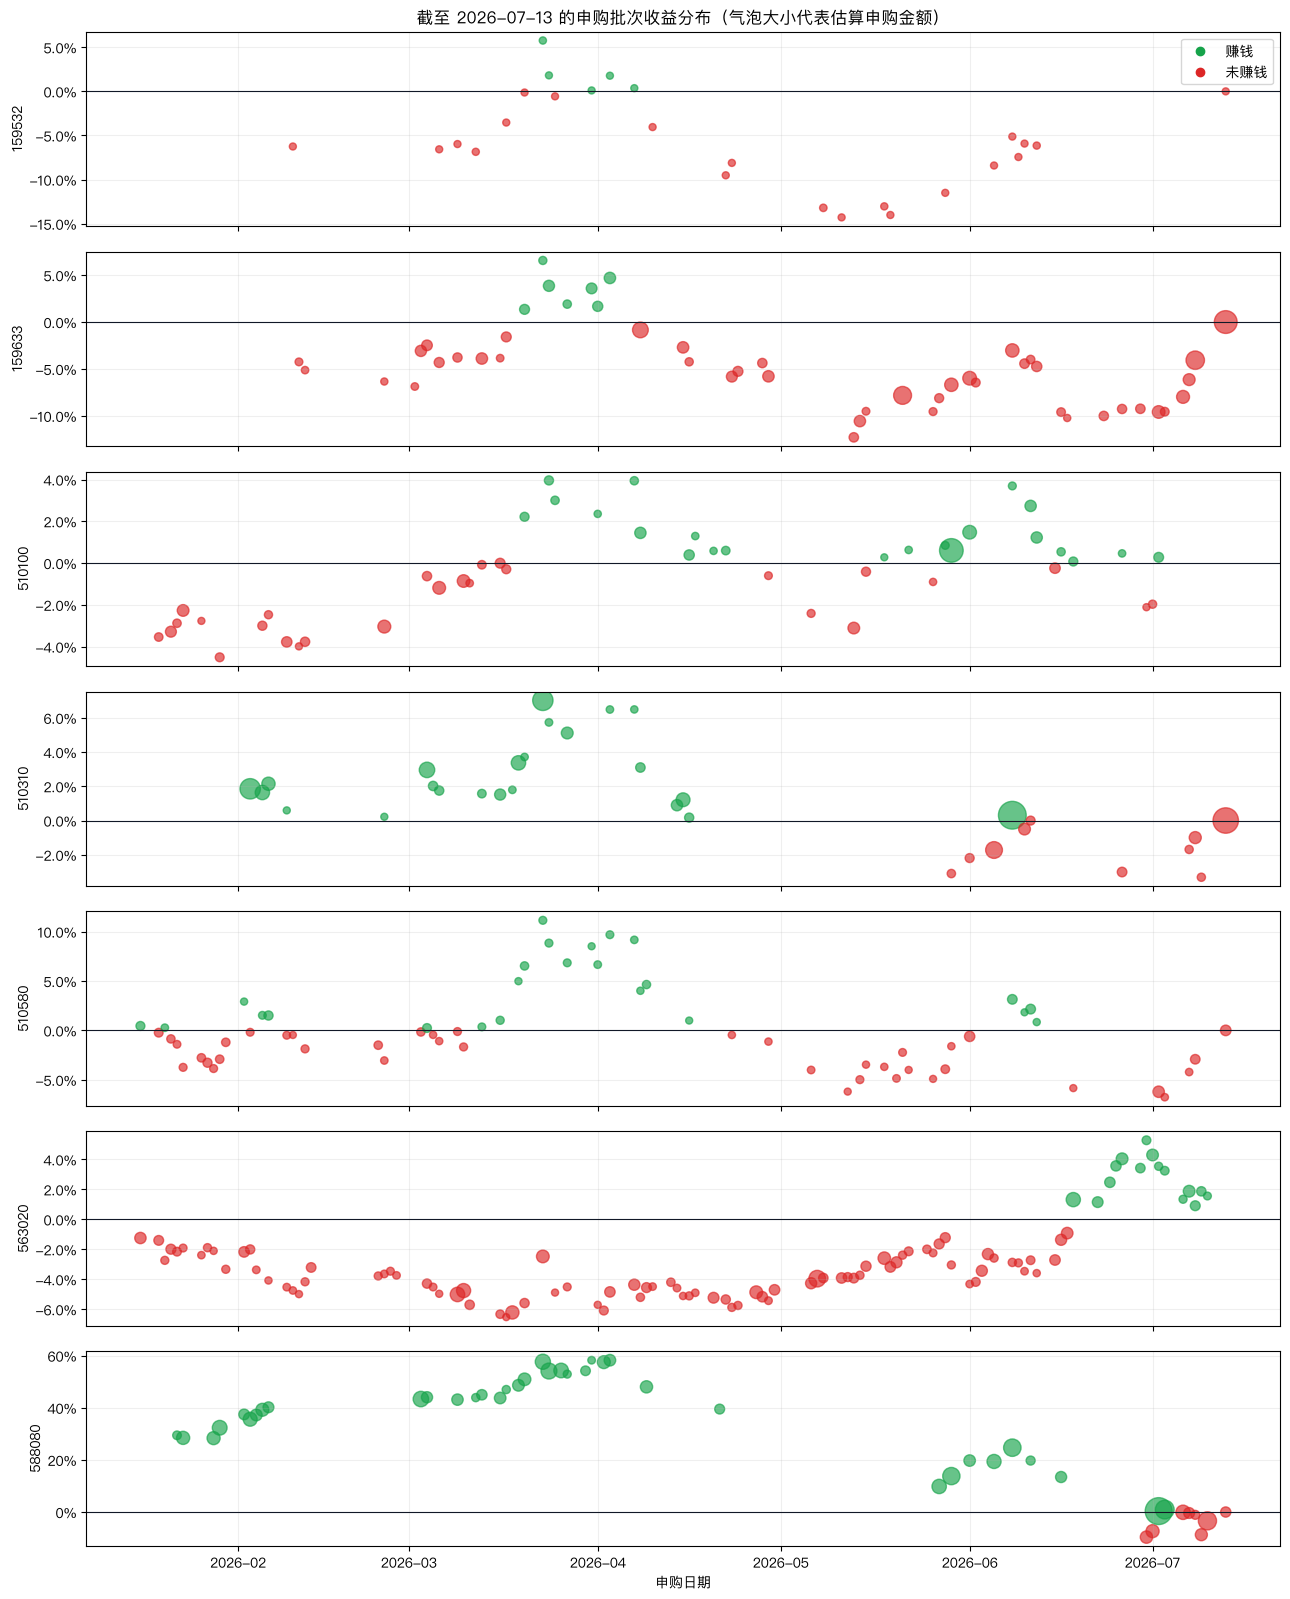

In [5]:
基金代码列表 = 汇总.loc[汇总['fund_code'] != 'ALL', 'fund_code'].tolist()
图, 坐标轴列表 = plt.subplots(len(基金代码列表), 1, figsize=(13, max(4, 2.3 * len(基金代码列表))), sharex=True)
最大申购金额 = 批次明细['估算申购金额'].max() if not 批次明细.empty else 1

for 坐标轴, 基金代码 in zip(坐标轴列表, 基金代码列表):
    数据 = 批次明细.loc[批次明细['fund_code'] == 基金代码]
    if 数据.empty:
        坐标轴.text(0.5, 0.5, '无正净申购批次', ha='center', va='center', transform=坐标轴.transAxes)
    else:
        气泡大小 = 25 + 375 * 数据['估算申购金额'] / 最大申购金额
        颜色 = 数据['赚钱'].map({True: '#16A34A', False: '#DC2626'})
        坐标轴.scatter(数据['申购日期'], 数据['持有收益率'], s=气泡大小, c=颜色, alpha=0.65)
    坐标轴.axhline(0, color='#111827', linewidth=0.8)
    坐标轴.yaxis.set_major_formatter(PercentFormatter(1))
    坐标轴.set_ylabel(基金代码)
    坐标轴.grid(alpha=0.2)

坐标轴列表[0].set_title(f'截至 {实际评价日} 的申购批次收益分布（气泡大小代表估算申购金额）')
坐标轴列表[0].legend(handles=[
    Line2D([], [], marker='o', linestyle='', color='#16A34A', label='赚钱'),
    Line2D([], [], marker='o', linestyle='', color='#DC2626', label='未赚钱'),
], loc='upper right')
坐标轴列表[-1].set_xlabel('申购日期')
plt.tight_layout()
plt.show()